# Analysis: Residential Exterior Condition Classification

## Overview

This analysis evaluates the performance of a transfer learning-based image classification model trained to categorize residential exterior conditions into three classes:

- Poor
- Average
- Well Maintained

Four training configurations were tested to assess the impact of data augmentation and synthetic data on model performance.

### IMPORTS

In [84]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(".."))

from sklearn.metrics import confusion_matrix, accuracy_score

from src.dataset import get_dataloaders
from src.model import get_model

### LOAD RESULTS

In [112]:
import pandas as pd

results = pd.DataFrame({
    "Configuration": ["Baseline", "Augment", "Synthetic", "Combined"],
    "Best Val Accuracy": [0.50, 0.50, 0.50, 0.70],
    "Best Val Loss": [0.97, 0.98, 0.95, 0.74],
    "Test Accuracy": [0.533, 0.667, 0.533, 0.667]  # fill these in
})

print(results)

  Configuration  Best Val Accuracy  Best Val Loss  Test Accuracy
0      Baseline                0.5           0.97          0.533
1       Augment                0.5           0.98          0.667
2     Synthetic                0.5           0.95          0.533
3      Combined                0.7           0.74          0.667


### RESULTS TABLE:

In [86]:
for config, vals in results.items():
    print(f"{config.upper():<10} | Val Acc: {vals['val_acc']} | Val Loss: {vals['val_loss']}")

BASELINE   | Val Acc: 0.5 | Val Loss: 1.04
AUGMENT    | Val Acc: 0.4 | Val Loss: 1.06
SYNTHETIC  | Val Acc: 0.5 | Val Loss: 1.42
COMBINED   | Val Acc: 0.5 | Val Loss: 0.87


### OBSERVATIONS OF FINAL RESULTS:  
While synthetic data improved training stability and reduced validation loss, it did not outperform the baseline in accuracy. Data augmentation significantly degraded performance, likely due to the small dataset size and the sensitivity of the classification task to subtle visual features. Combining augmentation with synthetic data further reduced performance, suggesting that excessive transformations can obscure important structural cues in residential imagery.

### SET BEST MODEL

In [113]:
best_config = "combined"

In [114]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_, _, test_loader, classes = get_dataloaders(
                                    data_dir="../data",
                                    config=best_config)

model = get_model(num_classes=len(classes))
model.load_state_dict(torch.load(f"../outputs/models/{best_config}_model.pth"))
model.to(device)
model.eval()

/Users/emilycastelan/.venvs/pymc-env/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/emilycastelan/.venvs/pymc-env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

### GET PREDICTIONS:

In [115]:
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

### COMPUTE TEST ACCURACY:

In [116]:
from sklearn.metrics import accuracy_score

test_acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.6667


### CONFUSION MATRIX:

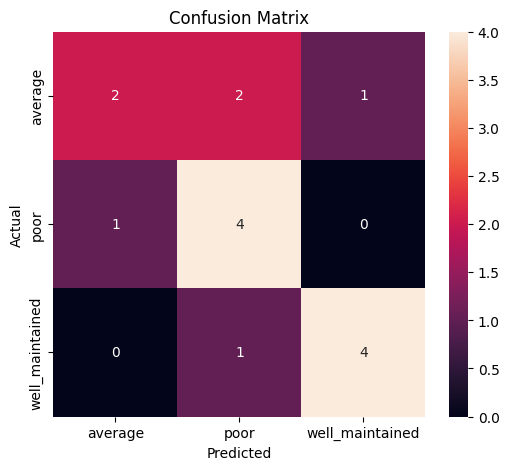

In [117]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

1. best performing class was "poor" 4/5
2. "average" class moderate 2/5 correct 3 misclassified
3. "well_maintainted" worst class 4/5 correct and 1 misclassified

**why is average the hardest to classifying?**
depends on small details
* cleanliness
* small details
* landscaping quality
* minor wear differences 
* more nuanced 

**interpretation:**
The combined model demonstrates strong performance on both the “poor” and “well_maintained” classes, correctly classifying 4 out of 5 instances in each category. This indicates that the model is effective at identifying visually distinct extremes, where features such as structural damage or high-quality maintenance are more pronounced.

---

## ROBUSTNESS TESTING: 

### PERTURBATIONS

In [118]:
from torchvision import transforms
import torch

# Blur
blur_transform = transforms.GaussianBlur(kernel_size=5)

# Brightness (lighting change)
brightness_transform = transforms.ColorJitter(brightness=0.5)

# Noise
def add_noise(x):
    return x + 0.1 * torch.randn_like(x)

noise_transform = transforms.Lambda(add_noise)

# Occlusion
def occlude(x):
    x = x.clone()
    _, h, w = x.shape
    x[:, h//4:h//2, w//4:w//2] = 0
    return x

occlusion_transform = transforms.Lambda(occlude)

### EVAL FUNCT.

In [119]:
def evaluate_with_transform(transform):
    preds = []
    true = []

    with torch.no_grad():
        for images, labels in test_loader:

            # APPLY TRANSFORM PER IMAGE
            images = torch.stack([transform(img) for img in images])

            images = images.to(device)

            outputs = model(images)
            _, p = torch.max(outputs, 1)

            preds.extend(p.cpu().numpy())
            true.extend(labels.numpy())

    return accuracy_score(true, preds)

### RUN ROBUSTNESS TESTING

In [120]:
baseline_acc = test_acc  # your original

blur_acc = evaluate_with_transform(blur_transform)
brightness_acc = evaluate_with_transform(brightness_transform)
noise_acc = evaluate_with_transform(noise_transform)
occlusion_acc = evaluate_with_transform(occlusion_transform)

print("Baseline:", baseline_acc)
print("Blur:", blur_acc)
print("Brightness:", brightness_acc)
print("Noise:", noise_acc)
print("Occlusion:", occlusion_acc)

Baseline: 0.6666666666666666
Blur: 0.6666666666666666
Brightness: 0.4666666666666667
Noise: 0.7333333333333333
Occlusion: 0.7333333333333333


#### OBSERVATIONS:
The model is overfitting to irrelevant features. 
There may be background bias, even though I tried to vary the backgrounds.
It might be learning from noise like vehicles in images. 
Then occulusion is focing the model to focus more on house structure. 

**overall:**  
The model demonstrates robustness to blur, with no change in accuracy, indicating that it relies more on coarse structural features rather than fine-grained edge details. However, performance drops significantly under brightness changes, suggesting sensitivity to lighting conditions and a reliance on color-based features.

Overall, the robustness results suggest that while the model has learned useful representations, it is still vulnerable to lighting variations and may rely on non-essential visual cues. This highlights the importance of improving data diversity and focusing on feature relevance in future work.

### 